# Gestion des données - Valeurs existantes
ou
# Recodage et création de variables

**Objectif pédagogique :** 
- Apprendre à recoder et à créer des variables
- Découvrir les fonctions `.replace()` et `pd.cut()`
- Apprendre à créer des scores
- Apprendre à comparer des variables

In [110]:
# Charger pandas
import pandas as pd

# Charger des données avec pandas depuis une URL
data_url = "https://raw.githubusercontent.com/datamisc/ts-2024/main/data.csv"
anes_data = pd.read_csv(data_url, compression="gzip", low_memory=False)


In [111]:
# Sélectionner un sous ensemble de variables et renommer
my_vars = [
    "V241042",  # a l'intention de voter ou non
    "V241043",  # pour qui a l'intention de voter
    "V241458x",  # age
    "V241177",  # autoplacement sur une échelle libéral-conservateur
    "V241156",  # Harris thermometer
    "V241157",  # Trump thermometer
    "V242425",  # Gestion covid par présidence
    "V241229",  # confiance gouvernement
    "V241233",  # corruption gouvernement
    "V241234",  # confiance aux gens
]

df = anes_data[my_vars]

df.columns = [
    "vote",
    "vote_int",
    "age",
    "ideologie",
    "harris_thrm",
    "trump_thrm",
    "covid",
    "conf_gouv",
    "conf_corrupt",
    "conf_gens",
]

df.head()


,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
0,1,2,50,6,0,100,4,5,2,3
1,1,3,41,4,50,50,3,5,2,3
2,1,1,44,2,90,0,2,4,3,3
3,1,2,45,99,50,70,2,4,4,4
4,1,2,80,4,5,60,4,5,2,4


## Recodage des variables à l'aide d'un masque/filtre

On peut utiliser les opérateurs relationnels (<>=) pour identifier les observations qui répondent à certains critères que nous souhaitons modifier.

On pourrait par exemple recoder la variable relative à l'intention de vote :

```
V241043 – PRE: FOR WHOM DOES R INTEND TO VOTE FOR PRESIDENT
-9. Refused
-8. Don’t know
-1. Inapplicable
1. Kamala Harris
2. Donald Trump
3. Robert F. Kennedy, Jr.
4. Cornel West
5. Jill Stein
6. Another candidate {SPECIFY}
```



In [112]:
# Recodage des valeurs avec un masque
# On selectionne la plage qui nous intéresse
new_df = df[
    (df["vote_int"] > 0) & (df["vote_int"] <= 6)
].copy()  # Creation d'un nouveau dataframe

In [113]:
new_df.describe()

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
count,4539.0,4539.000000,4539.000000,4539.000000,4539.000000,4539.000000,4539.000000,4539.000000,4539.000000,4539.000000
mean,1.0,1.648821,51.239700,14.269663,48.461996,39.611368,1.586252,3.522362,2.951311,2.759418
std,0.0,0.922303,20.239886,29.428364,38.135265,39.907298,2.745202,1.045724,1.138709,1.023015
min,1.0,1.000000,-2.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.0,1.000000,37.500000,3.000000,0.000000,0.000000,1.000000,3.000000,2.000000,2.000000
50%,1.0,1.000000,53.000000,4.000000,55.000000,30.000000,2.000000,4.000000,3.000000,3.000000
75%,1.0,2.000000,68.000000,6.000000,85.000000,85.000000,3.000000,4.000000,4.000000,3.000000
max,1.0,6.000000,80.000000,99.000000,100.000000,100.000000,4.000000,5.000000,5.000000,5.000000


In [114]:
# Puis recodage pour la valeur == 1
new_df["vote_int"] = new_df["vote_int"].astype(
    "object"
)  # Conversion pour pouvoir recoder avec des strings
mask = new_df["vote_int"] == 1
new_df.loc[mask, "vote_int"] = "K.Harris"


In [115]:
new_df

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
0,1,2,50,6,0,100,4,5,2,3
1,1,3,41,4,50,50,3,5,2,3
2,1,K.Harris,44,2,90,0,2,4,3,3
3,1,2,45,99,50,70,2,4,4,4
4,1,2,80,4,5,60,4,5,2,4
...,...,...,...,...,...,...,...,...,...,...
5513,1,2,53,3,50,70,1,2,3,3
5515,1,K.Harris,80,3,100,0,1,3,3,4
5517,1,K.Harris,69,3,85,0,2,3,3,3
5519,1,K.Harris,28,1,90,0,2,2,4,2


In [116]:
# Puis recodage pour la valeur == 2
mask = new_df["vote_int"] == 2
new_df.loc[mask, "vote_int"] = "D.Trump"


In [117]:
new_df["vote_int"].value_counts()


vote_int
K.Harris    2303
D.Trump     1910
3            169
6             95
5             36
4             26
Name: count, dtype: int64

### Hack-Time



In [118]:
# Terminer de recoder la variable `vote_int`


## Recodage des variables à l'aide de `replace()`

Recoder chaque catégorie une par une est plus que fastidieux !

Pour faciliter cette tâche, il est possible de recoder les variables à l'aide de la méthode `replace()`.

Recodons cette fois-ci la variable `covid` à l'aide de la méthode `.replace()` et de listes ou d'un dictionnaire !

```
V242425 - POST: CSES6-Q08B: PRESIDENT PERFORMANCE COVID
-9. Refused
-8. Don’t know
-7. Insuﬃcient partial, interview deleted
-6. No post interview
-5. Suﬃcient partial, breakoﬀ
-1. Inapplicable
1. Very good job
2. Good job
3. Bad job
4. Very bad job
```

In [119]:
# À quoi ressemble la variable `covid` ?
new_df["covid"].value_counts()

covid
 2    1607
 3     970
 4     783
 1     724
-6     362
-5      39
-7      35
-9      16
-8       3
Name: count, dtype: int64

In [120]:
# Créer deux listes avec les anciennes et les nouvelles modalités
old_labels = [1, 2, 3, 4]
new_labels = ["1. Very good job", "2. Good job", "3. Bad job", "4. Very bad job"]


In [121]:
new_df["covid"].replace(old_labels, new_labels)


0        4. Very bad job
1             3. Bad job
2            2. Good job
3            2. Good job
4        4. Very bad job
              ...       
5513    1. Very good job
5515    1. Very good job
5517         2. Good job
5519         2. Good job
5520          3. Bad job
Name: covid, Length: 4539, dtype: object

In [122]:
# Ça à l'air mieux !
new_df["covid"].replace(old_labels, new_labels).value_counts()

covid
2. Good job         1607
3. Bad job           970
4. Very bad job      783
1. Very good job     724
-6                   362
-5                    39
-7                    35
-9                    16
-8                     3
Name: count, dtype: int64

In [123]:
# Je peux aussi utiliser un dictionnaire pour faire le recodage
recode_dict = {
    1: "1. Very good job",
    2: "2. Good job",
    3: "3. Bad job",
    4: "4. Very bad job",
    -5: pd.NA,  # Missing value : Pensez à None, mais en différent
    -6: pd.NA,  # Missing value : Pensez à None, mais en différent
    -7: pd.NA,  # Missing value : Pensez à None, mais en différent
    -9: pd.NA,  # Missing value : Pensez à None, mais en différent
    -8: pd.NA,  # Missing value : Pensez à None, mais en différent
}

# Et voir ce que ça donne :
new_df["covid"].replace(recode_dict).value_counts()


covid
2. Good job         1607
3. Bad job           970
4. Very bad job      783
1. Very good job     724
Name: count, dtype: int64

In [124]:
# TODO: (pour trace j'ai décidé dessous) voir si vrai recodage propre avec dict ou si garder les labels pas complets
# CF AVISER AVEC MICKAEL SI C'ÉTAIT LE BUT AVEC LA VARIABLE QUI EST REMOBILISÉE PLUS BAS

# TODO: je décide pour simplifier de passer à un recodage propore
# Mais confirmer avec mickael si ok pour lui

# Une fois satisfaits, on peut sauvegarder/assigner à notre variable d'origine
new_df["covid"] = new_df["covid"].replace(recode_dict)
# Et on peut de nouveau jeter un oeil à la variable
new_df["covid"].value_counts(normalize=True)

covid
2. Good job         0.393487
3. Bad job          0.237512
4. Very bad job     0.191724
1. Very good job    0.177277
Name: proportion, dtype: float64

<Axes: xlabel='covid'>

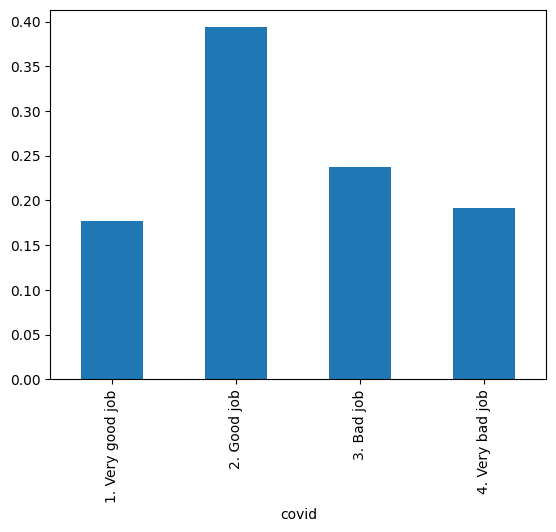

In [133]:
# @mickael le todo là dessous c'est si on avait gardé des mixed types
# J'ai fait le choix de partir sur la variable propre pour la clarté de la démo
# TODO : passage en string seul truc si on veut garder le sort index non ?
# Ou alors avoir nettoyé en entier
# mais doute avec la variable à la fin.

# new_df["covid"] = new_df["covid"].astype("string")

new_df["covid"].value_counts(normalize=True).sort_index().plot(kind="bar")

### Hack-Time

In [137]:
# Est-ce que les citoyens qui approuvent les mesures prises
# par le gouvernement pour gérer le COVID sont
# plutôt libéraux ou conservateurs ?
# CONSEIL : utilisez pd.crosstab !

## Filtrer ou recoder ?

Jusqu'à présent, nous avons généralement filtré les observations dont nous n'avions pas besoin sans réfléchir aux conséquences que cela pouvait avoir sur nos résultats. 

Or, si on applique plusieurs filtres, on ajoute des biais à notre ensemble de données, et on risque également de perdre une grande partie des données ! 
- **Avec moins de données, nous avons moins d'éléments pour tirer des conclusions !**

Essayons de prédire le résultat des élections à l'aide des données préélectorales !


In [71]:
# Filtrer toutes les observations qui ne sont pas Harris ou Trump
mask = df["vote_int"].between(1, 2)
filter_df = df[mask].copy()

# Changer les labels
vote_int_labels = {
    1: "K.Harris",
    2: "D.Trump",
}

filtered_output = (
    filter_df["vote_int"].replace(vote_int_labels).value_counts(normalize=True)
)
filtered_output

vote_int
K.Harris    0.546641
D.Trump     0.453359
Name: proportion, dtype: float64

In [ ]:
# Recoder les observations
mask = df["vote_int"] > 0
recoded_df = df[mask].copy()

# Conversion pour pouvoir recoder avec des strings
recoded_df["vote_int"] = recoded_df["vote_int"].astype("object")

# Garder toutes les autres intentions de vote recodées comme "Autre"
mask = recoded_df["vote_int"] > 2
recoded_df.loc[mask, "vote_int"] = "Other"

# Recoder les labels restants en utilisant le dictionnaire précédemment créé
recoded_df["vote_int"] = recoded_df["vote_int"].replace(vote_int_labels)

recoded_output = recoded_df["vote_int"].value_counts(normalize=True)
recoded_output


vote_int
K.Harris    0.507380
D.Trump     0.420798
Other       0.071822
Name: proportion, dtype: float64

In [75]:
print("La sortie en filtrant")
print(filtered_output)
print("==============================")
print("La sortie en recodant")
print(recoded_output)

La sortie en filtrant
vote_int
K.Harris    0.546641
D.Trump     0.453359
Name: proportion, dtype: float64
La sortie en recodant
vote_int
K.Harris    0.507380
D.Trump     0.420798
Other       0.071822
Name: proportion, dtype: float64


## Créer de nouvelles variables (~ Ajout de nouvelles colonnes)

Lorsque vous recodez des variables, vous pouvez ajouter une nouvelle variable au jeu de données d'origine afin de conserver la version originale de votre variable.

![](https://pandas.pydata.org/docs/_images/05_newcolumn_1.svg)




In [76]:
recoded_df

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
0,1,D.Trump,50,6,0,100,4,5,2,3
1,1,Other,41,4,50,50,3,5,2,3
2,1,K.Harris,44,2,90,0,2,4,3,3
3,1,D.Trump,45,99,50,70,2,4,4,4
4,1,D.Trump,80,4,5,60,4,5,2,4
...,...,...,...,...,...,...,...,...,...,...
5513,1,D.Trump,53,3,50,70,1,2,3,3
5515,1,K.Harris,80,3,100,0,1,3,3,4
5517,1,K.Harris,69,3,85,0,2,3,3,3
5519,1,K.Harris,28,1,90,0,2,2,4,2


In [77]:
recoded_df["my_new_var"] = 0
recoded_df

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens,my_new_var
0,1,D.Trump,50,6,0,100,4,5,2,3,0
1,1,Other,41,4,50,50,3,5,2,3,0
2,1,K.Harris,44,2,90,0,2,4,3,3,0
3,1,D.Trump,45,99,50,70,2,4,4,4,0
4,1,D.Trump,80,4,5,60,4,5,2,4,0
...,...,...,...,...,...,...,...,...,...,...,...
5513,1,D.Trump,53,3,50,70,1,2,3,3,0
5515,1,K.Harris,80,3,100,0,1,3,3,4,0
5517,1,K.Harris,69,3,85,0,2,3,3,3,0
5519,1,K.Harris,28,1,90,0,2,2,4,2,0


In [78]:
# On peut également supprimer une colonne à l'aide de la méthode drop.
# Voyons à quoi ressemble le recoded_df si nous supprimons/dropons la variable.
recoded_df.drop("my_new_var", axis=1)

,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens
0,1,D.Trump,50,6,0,100,4,5,2,3
1,1,Other,41,4,50,50,3,5,2,3
2,1,K.Harris,44,2,90,0,2,4,3,3
3,1,D.Trump,45,99,50,70,2,4,4,4
4,1,D.Trump,80,4,5,60,4,5,2,4
...,...,...,...,...,...,...,...,...,...,...
5513,1,D.Trump,53,3,50,70,1,2,3,3
5515,1,K.Harris,80,3,100,0,1,3,3,4
5517,1,K.Harris,69,3,85,0,2,3,3,3
5519,1,K.Harris,28,1,90,0,2,2,4,2


In [79]:
# Une fois satisfaits du résultat, on sauve !
recoded_df = recoded_df.drop("my_new_var", axis=1)

## Hack-Time

In [ ]:
# Ajoutez une nouvelle variable binaire qui prend la valeur 1 lorsque
# le répondant a l'intention de voter pour Trump.
# Nommez cette variable « vote_trump ».


0       1
1       0
2       0
3       1
4       1
       ..
5516    0
5517    0
5518    0
5519    0
5520    1
Name: test, Length: 5521, dtype: int64

Ajoutons maintenant des catégories d'age à notre jeu de données ! 

In [ ]:
# Mais comment ?
mask = recoded_df["age"] >= 18
recoded_df["age_cat"] = "18-35"
mask = recoded_df["age"] >= 36
recoded_df["age_cat"] = "36-50"
mask = recoded_df["age"] >= 51
recoded_df["age_cat"] = "51-65"
...
...
...

Encore une fois, c'est très fastidieux…

## La fonction cut
La fonction `pd.cut()` nous permet de transformer une variable continue en catégories !

In [92]:
# TODO : Léo -> retrouver le truc qui est chelou dans la doc avec les bornes
recoded_df["age_cat"] = pd.cut(
    df["age"], bins=[17, 35, 50, 65, 80], labels=["18-35", "36-50", "51-65", "66+"]
)
recoded_df


,vote,vote_int,age,ideologie,harris_thrm,trump_thrm,covid,conf_gouv,conf_corrupt,conf_gens,age_cat
0,1,D.Trump,50,6,0,100,4,5,2,3,36-50
1,1,Other,41,4,50,50,3,5,2,3,36-50
2,1,K.Harris,44,2,90,0,2,4,3,3,36-50
3,1,D.Trump,45,99,50,70,2,4,4,4,36-50
4,1,D.Trump,80,4,5,60,4,5,2,4,66+
...,...,...,...,...,...,...,...,...,...,...,...
5513,1,D.Trump,53,3,50,70,1,2,3,3,51-65
5515,1,K.Harris,80,3,100,0,1,3,3,4,66+
5517,1,K.Harris,69,3,85,0,2,3,3,3,66+
5519,1,K.Harris,28,1,90,0,2,2,4,2,18-35


<Axes: xlabel='age_cat'>

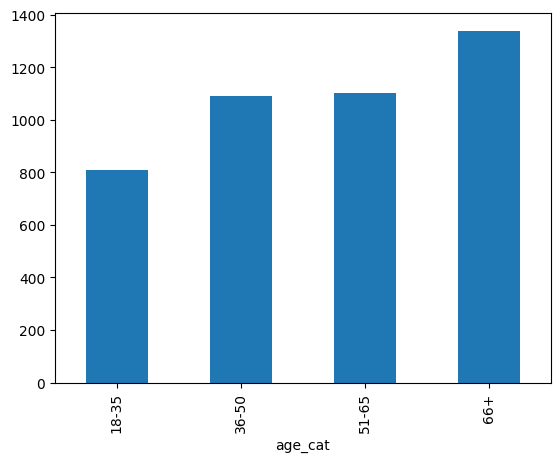

In [93]:
recoded_df["age_cat"].value_counts().sort_index().plot(kind="bar")


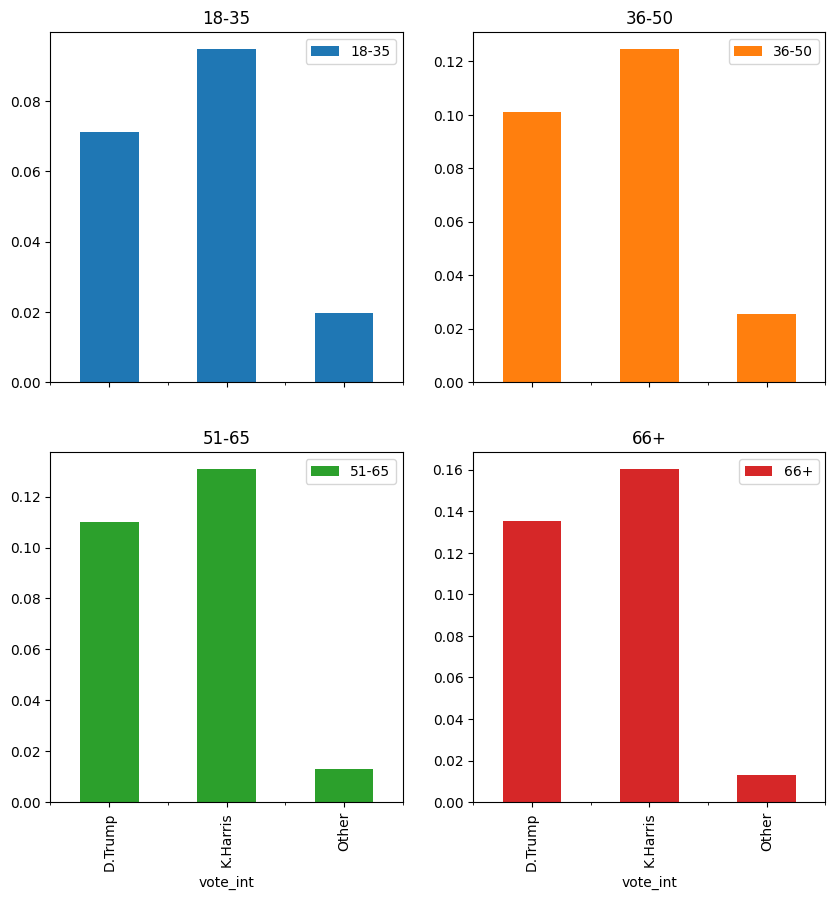

In [100]:
pd.crosstab(recoded_df["vote_int"], recoded_df["age_cat"], normalize=True).plot(
    kind="bar", subplots=True, figsize=(10, 10), layout=(2, 2)
);
# TIPS : ce petit `;` qu'on utilise parfois c'est pour nettoyer la sortie

### Hack-Time

In [ ]:
# Ajouter une version nettoyée de la variable covid nommée « clean_covid ».

In [ ]:
# Quelle tranche d'âge approuve le plus la manière
# dont le gouvernement gère la crise du Covid ?

## Créer un score (Additive Scale)
Les scores combinent plusieurs items d'enquête en une seule mesure. Pour chaque ligne, on va additionner les réponses aux variables d'intérêt.

### Créer un score de confiance politique

In [101]:
# On selectionne les trois variables liées à la confiance
trust_scale_vars = ["conf_gouv", "conf_corrupt", "conf_gens"]
df[trust_scale_vars]

,conf_gouv,conf_corrupt,conf_gens
0,5,2,3
1,5,2,3
2,4,3,3
3,4,4,4
4,5,2,4
...,...,...,...
5516,5,1,4
5517,3,3,3
5518,4,3,3
5519,2,4,2


In [102]:
# Recodage des valeurs spécifiques (missing values du questionnaire)
old_labels = [-1, -2, -3, -4, -5, -6, -7, -8, -9]
df[trust_scale_vars] = df[trust_scale_vars].replace(old_labels, pd.NA)

In [103]:
# Inversons les échelles pour que les valeurs plus élevées correspondent à plus de confiance
# Il faut vérifier dans le codebook pour comprendre la direction
df["conf_gouv"] = 6 - df["conf_gouv"]
df["conf_gens"] = 6 - df["conf_gens"]

# Vous avez remarqué que l'on n'a pas inversé la variable `conf_corrupt`/V241233.
# Pourquoi ?

In [104]:
# Création du score/échelle additive en addition les trois items
df["trust_scale"] = df[trust_scale_vars].sum(axis=1)


count     5521
unique      16
top          9
freq       990
Name: trust_scale, dtype: int64


<Axes: xlabel='trust_scale'>

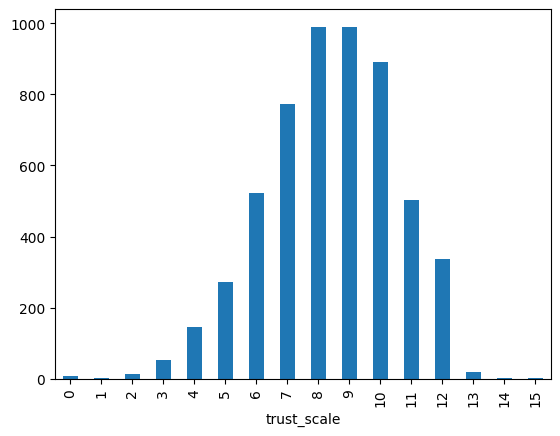

In [108]:
# Vérifions si tout à l'air ok !
print(df["trust_scale"].describe())
df["trust_scale"].value_counts().sort_index().plot(kind="bar")